In [1]:
# validating emails and handling edge cases
"""
    A way I am just thinking is setting up rules that allow us to determine if the email is valid or not,
    for example does it contain @ symbol, then known email domain like gmail, outlook, yahoo, once this are finished
    we could extend it to check general structure designation@email_provider.domain
"""

list_emails = ['ramirezcarlos292@gmail.com', 'ramirezcarlos.292@outlook.es', 'cramir73@its.jnj.com']

In [6]:
# identify common elements like @, email provider or proper domain at the end of the input email
def email_val_method1(email):
    # first rule: does it contain @
    at = '@' in email
    known_providers = ["gmail", "outlook", "yahoo", "hotmail"]
    prov = False
    for provider in known_providers:
        if provider in email:
            prov = True
            break
        
    return at * prov

for email in list_emails:
    print(f" {email} is valid? {email_val_method1(email)}")

 ramirezcarlos292@gmail.com is valid? 1
 ramirezcarlos.292@outlook.es is valid? 1
 cramir73@its.jnj.com is valid? 0


In [5]:
import regex as re
def email_val_regex(email):
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    pattern2 = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    if re.match(pattern2, email): 
        return 'Yes'
    else: 
        return 'No'
    
for email in list_emails:
    print(f" {email} is valid? {email_val_regex(email)}")

 ramirezcarlos292@gmail.com is valid? Yes
 ramirezcarlos.292@outlook.es is valid? Yes
 cramir73@its.jnj.com is valid? Yes


In [7]:
#https://pypi.org/project/email-validator/

from email_validator import validate_email, EmailNotValidError
def is_valid_email(email):
    try:
        emailinfo = validate_email(email, check_deliverability=True)
        return True, emailinfo.normalized
    except EmailNotValidError as e:
        return False, str(e)

for email in list_emails:
    is_valid, result = is_valid_email(email)

    if is_valid: print(f"Email '{email}' is valid. Normalized form: {result}")
    else: print(f"Email '{email}' is invalid. Reason: {result} ")

ModuleNotFoundError: No module named 'email_validator'

In [ ]:


for email in list_emails:
    email_val_method1(email)
    

In [17]:
students_scores = [75, 82, 90, 60, 85, 78, 95, 88, 70, 80]
students_scores.sort()
print(f" Students scores {students_scores}")
mean = sum(students_scores)/len(students_scores)
print(f" Mean: {mean}")

mid = len(students_scores) // 2
median = (students_scores[mid] + students_scores[mid+1]) / 2
print(f" Median: {median}")

accum = 0
for score in students_scores:
    accum += (score - mean)**2

variance = accum / (len(students_scores)-1)
print(f" Variance: {variance}")
import math
std = math.sqrt(variance)

print(f" Standard Deviation:  {std}")

    

 Students scores [60, 70, 75, 78, 80, 82, 85, 88, 90, 95]
 Mean: 80.3
 Median: 83.5
 Variance: 105.1222222222222
 Standard Deviation:  10.252912865240893


8
[19, 22]
[43, 50]


 Matrix of size 3: [[11, 11, 11], [4, 4, 4], [6, 6, 6]]
Matrix A: [[5, 5, 5], [5, 5, 5], [1, 1, 1]], Matrix B: [[4, 4, 4], [10, 10, 10], [7, 7, 7]], Result Matrix [[105, 105, 105], [105, 105, 105], [21, 21, 21]], # operations performed: 27
[1, 8, 27, 64, 125, 216, 343, 512, 729, 1000, 1331, 1728, 2197, 2744, 3375, 4096, 4913, 5832, 6859, 8000, 9261, 10648, 12167, 13824, 15625, 17576, 19683, 21952, 24389, 27000, 29791, 32768, 35937, 39304, 42875, 46656, 50653, 54872, 59319, 64000, 68921, 74088, 79507, 85184, 91125, 97336, 103823, 110592, 117649, 125000, 132651, 140608, 148877, 157464, 166375, 175616, 185193, 195112, 205379, 216000, 226981, 238328, 250047, 262144, 274625, 287496, 300763, 314432, 328509, 343000, 357911, 373248, 389017, 405224, 421875, 438976, 456533, 474552, 493039, 512000, 531441, 551368, 571787, 592704, 614125, 636056, 658503, 681472, 704969, 729000, 753571, 778688, 804357, 830584, 857375, 884736, 912673, 941192, 970299, 1000000, 1030301, 1061208, 1092727, 1124864, 1157

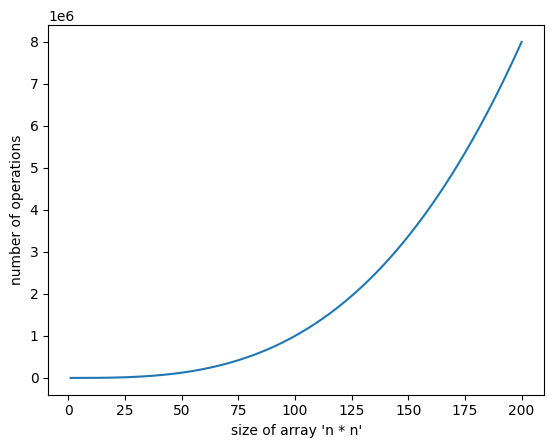

In [ ]:
import random
import matplotlib.pyplot as plt
"""
    input: n is the size of the squared matrix
    process: creates a matrix of the specified size, the elements
    are random numbers from 1, to 10.
    output: returns a matrix of the size specified.
"""
def matrix_gen(n=2):
    generated_matrix = [[random.randint(1, 11)] * n for _ in range(n)]
    return generated_matrix



def matrix_multiplication(A, B, n=2):   
    # Matriz resultado inicializada con ceros
    result = [[0] * n for _ in range(n)]
    counter = 0
    # Multiplicación de matrices
    for i in range(n):  # Filas de A
        for j in range(n):  # Columnas de B
            for k in range(n):  # Elementos comunes
                result[i][j] += A[i][k] * B[k][j]
                counter += 1
    
    return result, counter

# test matrix_gen
n = 3
matrix = matrix_gen(n)
print(f"Matrix of size {n}: {matrix}")

# test matrix multplication
A = matrix_gen(n)
B = matrix_gen(n)
result, counter = matrix_multiplication(A, B, n)
print(f"Matrix A: {A}, Matrix B: {B}, Result Matrix {result}, # operations performed: {counter}")

if __name__ == "__main__":
    ops_count, n_runtime = [], []
    for n in range(1, 201):
        # generate square matrices of size n
        A = matrix_gen(n)
        B = matrix_gen(n)
        # perform multiplication A * B
        counter = matrix_multiplication(A, B, n)[1]
        # store operations made in the inner loop of matrix_multiplication
        ops_count.append(counter)
        # store size of squared matrix
        n_runtime.append(n)
    # print(ops_count)
    # print(n_runtime)
    
    plt.plot(n_runtime, ops_count)
    plt.xlabel("size of array 'n * n'")
    plt.ylabel("number of operations")
    plt.show()

In [3]:
result = ""
n = 1000
while n > 0:
    result = str(n % 2) + result
    n //= 2
print(result)

1111101000


In [4]:
n = 1000
for i in range(n):
    for j in range(n - 1, i - 1, -1):
        print(i, j)


0 999
0 998
0 997
0 996
0 995
0 994
0 993
0 992
0 991
0 990
0 989
0 988
0 987
0 986
0 985
0 984
0 983
0 982
0 981
0 980
0 979
0 978
0 977
0 976
0 975
0 974
0 973
0 972
0 971
0 970
0 969
0 968
0 967
0 966
0 965
0 964
0 963
0 962
0 961
0 960
0 959
0 958
0 957
0 956
0 955
0 954
0 953
0 952
0 951
0 950
0 949
0 948
0 947
0 946
0 945
0 944
0 943
0 942
0 941
0 940
0 939
0 938
0 937
0 936
0 935
0 934
0 933
0 932
0 931
0 930
0 929
0 928
0 927
0 926
0 925
0 924
0 923
0 922
0 921
0 920
0 919
0 918
0 917
0 916
0 915
0 914
0 913
0 912
0 911
0 910
0 909
0 908
0 907
0 906
0 905
0 904
0 903
0 902
0 901
0 900
0 899
0 898
0 897
0 896
0 895
0 894
0 893
0 892
0 891
0 890
0 889
0 888
0 887
0 886
0 885
0 884
0 883
0 882
0 881
0 880
0 879
0 878
0 877
0 876
0 875
0 874
0 873
0 872
0 871
0 870
0 869
0 868
0 867
0 866
0 865
0 864
0 863
0 862
0 861
0 860
0 859
0 858
0 857
0 856
0 855
0 854
0 853
0 852
0 851
0 850
0 849
0 848
0 847
0 846
0 845
0 844
0 843
0 842
0 841
0 840
0 839
0 838
0 837
0 836
0 835
0 834
0 83